In [30]:
import torch
import numpy as np
from sklearn.preprocessing import StandardScaler
import umap
from sklearn.manifold import TSNE  # for dimension reduction
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

In [31]:
embeddings_dict = torch.load('fm-rna_embeddings.pt')

In [32]:
embeddings = [torch.mean(emb, dim=0).numpy() for emb in embeddings_dict.values()]
embeddings = np.array(embeddings)

In [33]:
embeddings.shape

(8627, 640)

In [34]:
# tsne = TSNE(n_components=2, random_state=42)
# reduced_embeddings = tsne.fit_transform(embeddings)
# print(reduced_embeddings.shape)

In [35]:
scaled_data = StandardScaler().fit_transform(embeddings)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
reduced_embeddings = reducer.fit_transform(scaled_data)

c:\Users\Julius\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


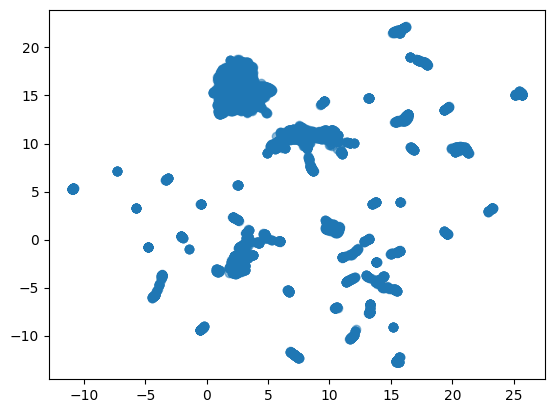

In [36]:
plt.scatter(reduced_embeddings[:,0], reduced_embeddings[:,1], alpha=0.5)

In [37]:
import os

In [38]:
os.getcwd()

'c:\\Julius_SSD\\Stanford\\Stanford_3_JuniorYear\\Stanford_3_3_Spring\\CS229\\cs229_rna_folding\\modular_setup_bigger_dataset'

In [39]:
df = pd.read_parquet('../kinfold_simulations/SLURM/dataset_with_fpts.parquet')

In [40]:
mask_rows = df['fpts'].apply(lambda arr: not np.any(np.isnan(arr)))

In [52]:
for row in embeddings_dict.keys():
    #print(int(row))
    if not mask_rows[int(row)]:
        print(row)

3995
4108
4235
4427
4445
4514
4515
4620
4659
5078
5207
5218
5378
5717
5734
5847
5921
5958
5969
6017
6043
6053
6067
6109
6113
6124
6130
6132
6143
6152
6237
6251
6279
6329
6343
6344
6362
6382
6389
6391
6419
6441
6447
6461
6491
6537
6556
6572
6634
6639
6692
6695
6764
6771
6825
6863
6890
6893
6909
6931
6934
6953
6963
6970
7017
7018
7031
7040
7050
7057
7071
7087
7102
7118
7127
7128
7155
7159
7162
7165
7168
7169
7171
7179
7193
7195
7205
7207
7215
7216
7222
7224
7227
7228
7232
7234
7236
7241
7242
7254
7256
7257
7266
7290
7311
7316
7318
7342
7364
7365
7372
7378
7383
7392
7396
7402
7406
7408
7412
7429
7432
7438
7451
7472
7478
7484
7488
7493
7499
7533
7549
7552
7579
7588
7599
7602
7604
7613
7639
7646
7647
7659
7670
7683
7691
7701
7712
7719
7733
7757
7762
7773
7778
7782
7790
7791
7796
7808
7811
7816
7829
7838
7841
7845
7849
7856
7874
7879
7884
7888
7889
7896
7905
7911
7917
7919
7922
7924
7929
7940
7941
7944
7947
7954
7961
7962
7964
7966
7969
7977
7998
8007
8013
8019
8022
8026
8035
8037
8045
8053


In [48]:
embeddings_dict_subset = {}
for row in embeddings_dict.keys():
    #print(int(row))
    if mask_rows[int(row)]:
        embeddings_dict_subset[row] = embeddings_dict[row]

In [50]:
torch.save(embeddings_dict_subset, 'fm-rna_embeddings_subset.pt')

In [51]:
import torch
d = torch.load("fm-rna_embeddings_subset.pt")
print(len(d), type(next(iter(d.keys()))))
print('7552' in d, 7552 in d)

8311 <class 'str'>
False False


In [16]:
reduced_embeddings_subset = reduced_embeddings[mask_rows]

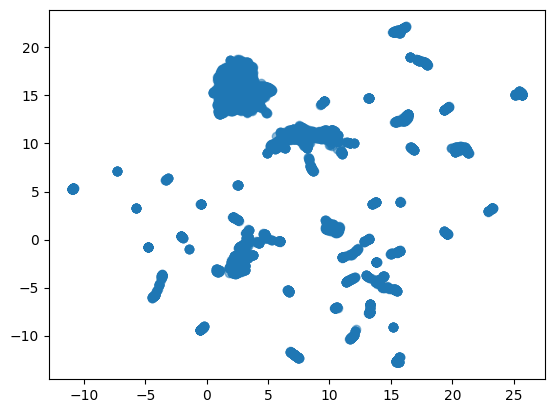

In [17]:
plt.scatter(reduced_embeddings_subset[:,0], reduced_embeddings_subset[:,1], alpha=0.5)

In [18]:
reduced_embeddings_subset.shape

(8311, 2)

In [19]:
arr_seqlength = np.loadtxt('../kinfold_simulations/SLURM/arr_seqlength.txt')
arr_medlogfpt = np.loadtxt('../kinfold_simulations/SLURM/arr_medlogfpt.txt')

In [20]:
arr_medlogfpt.shape

(8311,)

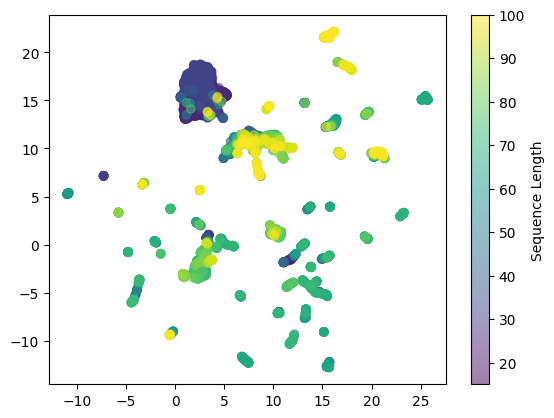

In [28]:
plt.scatter(reduced_embeddings_subset[:,0], reduced_embeddings_subset[:,1], alpha=0.5,
            c=arr_seqlength, cmap='viridis')

plt.colorbar(label='Sequence Length')

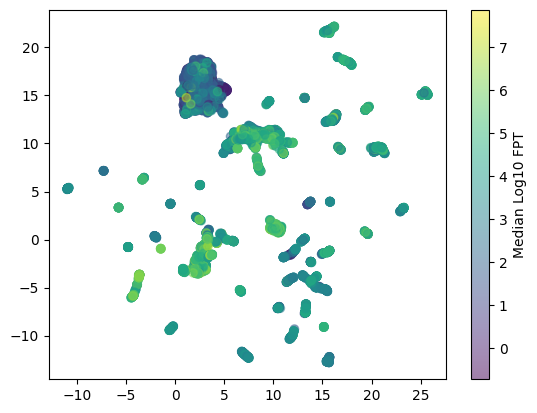

In [29]:
plt.scatter(reduced_embeddings_subset[:,0], reduced_embeddings_subset[:,1], alpha=0.5,
            c=arr_medlogfpt, cmap='viridis')

plt.colorbar(label='Median Log10 FPT')